In [1]:
# Initialization
import pandas as pd 
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt

class df_data():
  def __init__(self):
    self.gentoo = pd.read_csv('../data/gentoo_bugs_before_2012.csv')
    self.kde = pd.read_csv('../data/kde_bugs_before_2012.csv')
    self.suse = pd.read_csv('../data/suse_bugs_before_2012.csv')

data = df_data()

data.kde.columns

Index(['last_change_time', 'assigned_to', 'status', 'creation_time', 'creator',
       'severity', 'product', 'assigned_to_detail', 'id', 'priority',
       'component', 'creator_detail', 'resolution', 'dupe_of'],
      dtype='object')

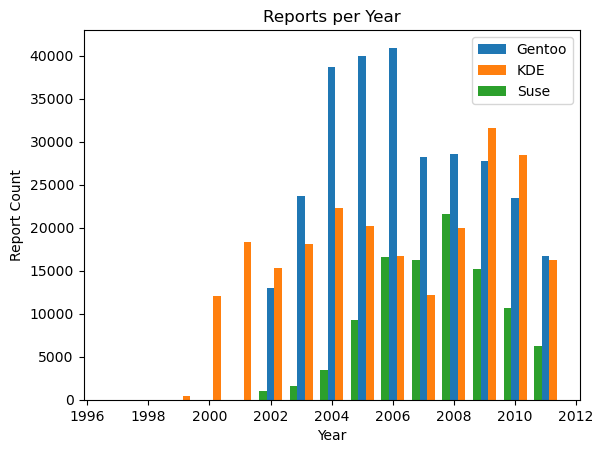

In [2]:
# Figure 1 Block
def get_tickets_per_year(df): 
    # Oldest ticket is 1997, latest is 2011   
    full_year_list = [dt.datetime.fromisoformat(d).year for d in df['creation_time']]
    year_list, counts = np.unique(full_year_list, return_counts=True)
  
    return year_list, counts

def create_tickets_per_year_plot(data):
  gentoo_years, gentoo_counts = get_tickets_per_year(data.gentoo)
  kde_years, kde_counts = get_tickets_per_year(data.kde)
  suse_years, suse_counts = get_tickets_per_year(data.suse)  
  
  fig, ax = plt.subplots()
  w = 0.25
  ax.bar(gentoo_years, gentoo_counts, width=w, label='Gentoo')
  ax.bar(kde_years + w, kde_counts, width=w, label='KDE')
  ax.bar(suse_years - w, suse_counts, width=w, label='Suse')  
  ax.set_title('Reports per Year')
  ax.set_xlabel('Year')
  ax.set_ylabel('Report Count')
  ax.legend()
  plt.show()

create_tickets_per_year_plot(data)  

In [14]:
# Figure 2 Block
# X Year, Y Percent, Line = Report Type, 1 Plot per Gentoo, KDE, Suse

def get_each_report_type_count(df):
  report_type_counts = {}

  for resolution in df['resolution'].unique():
    report_type_counts[resolution] = len(df.loc[(df['resolution'] == resolution)])  

  for key in report_type_counts.keys():
    print(f"{key}: {report_type_counts[key]}")
  
print("GENTOO")
get_each_report_type_count(data.gentoo)

print("\nKDE")
get_each_report_type_count(data.kde)

print("\nSUSE")
get_each_report_type_count(data.suse)


  


GENTOO
FIXED: 175088
DUPLICATE: 41499
INVALID: 20942
REMIND: 247
TEST-REQUEST: 3986
WONTFIX: 11849
LATER: 2167
CANTFIX: 2952
WORKSFORME: 7763
NEEDINFO: 7116
OBSOLETE: 433
UPSTREAM: 5615
nan: 0

KDE
FIXED: 103752
DUPLICATE: 57446
WONTFIX: 7638
nan: 0
INVALID: 20431
UNMAINTAINED: 6426
WORKSFORME: 25707
LATER: 928
REMIND: 1111
WAITINGFORINFO: 791
UPSTREAM: 2615
DOWNSTREAM: 1525
BACKTRACE: 64
MOVED: 13

SUSE
FIXED: 56608
WONTFIX: 8578
DUPLICATE: 12088
INVALID: 9184
UPSTREAM: 2002
WORKSFORME: 4183
MOVED: 763
FEATURE: 633
NORESPONSE: 3330
nan: 0
